# 03 — Modeling: Train/Test Split

Starts from `data/processed/crop_loss_model_ready.csv` (the clean, final
output of `02_feature_exploration.ipynb` — 12 columns, 72,762 rows, 0
missing values, 0 duplicates, `household_id` still included and the data
still whole). This notebook's first job: split it into train/test sets
without leaking a household across both sides.

In [1]:
import pandas as pd

# household_id explicitly as str -- see CLAUDE.md's float-precision gotcha.
df_model = pd.read_csv("../data/processed/crop_loss_model_ready.csv", dtype={"household_id": str})
print(df_model.shape)
df_model.head()

(72762, 12)


,household_id,crop_name,survey_year,household_size,region_code,is_rural,region_name,rainfall_belg_mm,rainfall_belg_pct_of_avg,rainfall_meher_mm,rainfall_meher_pct_of_avg,loss_occurred
0,1010101601002,MAIZE,2011,8.0,1.0,1.0,Tigray,120.648096,112.0,643.046036,95.0,0
1,1010101601002,MAIZE,2013,9.0,1.0,1.0,Tigray,72.747426,67.5,610.313750,90.2,0
2,1010101601002,MAIZE,2015,8.0,1.0,1.0,Tigray,111.048456,103.1,555.302842,82.0,0
3,1010101601002,MILLET,2011,8.0,1.0,1.0,Tigray,120.648096,112.0,643.046036,95.0,0
4,1010101601002,MILLET,2013,9.0,1.0,1.0,Tigray,72.747426,67.5,610.313750,90.2,0


## Train/test split — grouped by `household_id`

A household can report multiple crops, so a naive random split could put
the same household's rows on both sides of train/test, letting a model
partly recognize a specific household instead of learning a generalizable
pattern. `GroupShuffleSplit` (not plain `train_test_split`, which has no
`groups` parameter) keeps every row from a given household entirely on one
side. Verified below: zero `household_id` overlap, and the loss rate in
each split stays close to the full dataset's rate.

In [2]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df_model, groups=df_model["household_id"]))

train_df = df_model.iloc[train_idx].copy()
test_df = df_model.iloc[test_idx].copy()

overlap = set(train_df["household_id"]) & set(test_df["household_id"])

print("train:", train_df.shape, "| test:", test_df.shape)
print("household_id overlap between train/test:", len(overlap))
print("train loss rate:", train_df["loss_occurred"].mean().round(3))
print("test loss rate:", test_df["loss_occurred"].mean().round(3))

train: (58343, 12) | test: (14419, 12)
household_id overlap between train/test: 0
train loss rate: 0.067
test loss rate: 0.068


## Encode features

Building `X`/`y` from an explicit whitelist rather than dropping columns —
safer, since `household_id` (grouping key) and `region_name` (display label,
duplicate of `region_code`) can never leak into the model even if
`df_model` gains columns later.

- **Categorical** (`crop_name`, `region_code`, `survey_year`): one-hot
  encoded. `crop_name` has ~188 categories, but one-hot is still the right
  default here — it doesn't impose a false ordering the way integer-coding
  would, and with 58k+ training rows the extra width is fine. The encoder is
  **fit on train only** and applied to test with `handle_unknown="ignore"`
  (any category test has that train never saw becomes all-zeros, rather than
  erroring or leaking test-set category information back into the encoding).
- **Numeric** (`household_size`, `is_rural`, the 4 rainfall columns): used
  as-is, no scaling — tree-based models (the planned direction) don't need
  it, and it's simple to add later if a linear model wants it.

In [3]:
from sklearn.preprocessing import OneHotEncoder

CATEGORICAL_COLS = ["crop_name", "region_code", "survey_year"]
NUMERIC_COLS = ["household_size", "is_rural", "rainfall_belg_mm", "rainfall_belg_pct_of_avg",
                "rainfall_meher_mm", "rainfall_meher_pct_of_avg"]
TARGET_COL = "loss_occurred"

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(train_df[CATEGORICAL_COLS])

train_encoded = pd.DataFrame(
    encoder.transform(train_df[CATEGORICAL_COLS]),
    columns=encoder.get_feature_names_out(CATEGORICAL_COLS),
    index=train_df.index,
)
test_encoded = pd.DataFrame(
    encoder.transform(test_df[CATEGORICAL_COLS]),
    columns=encoder.get_feature_names_out(CATEGORICAL_COLS),
    index=test_df.index,
)

X_train = pd.concat([train_df[NUMERIC_COLS], train_encoded], axis=1)
X_test = pd.concat([test_df[NUMERIC_COLS], test_encoded], axis=1)
y_train = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train loss rate:", y_train.mean().round(3), "| y_test loss rate:", y_test.mean().round(3))
print("\ncategories per encoded column (first 10):")
print(list(encoder.get_feature_names_out(CATEGORICAL_COLS))[:10])

X_train: (58343, 144) | X_test: (14419, 144)
y_train loss rate: 0.067 | y_test loss rate: 0.068

categories per encoded column (first 10):
['crop_name_AMBOSHIKA', 'crop_name_APPLES', 'crop_name_AVOCADOS', 'crop_name_BANANAS', 'crop_name_BARLEY', 'crop_name_BEER ROOT', 'crop_name_BEERROOT', 'crop_name_BLACK CUMIN', 'crop_name_BLACK PEPPER', 'crop_name_BLACKCUMIN']


## Sanity check — X/y ready for modeling

Confirms the encoding step didn't silently break anything before fitting
any model: no `NaN`s in `X_train`/`X_test`, every column fully numeric,
`X`/`y` row-aligned by index on both sides, and `X_train`/`X_test` have
identical columns (so a model trained on one can score the other).

In [4]:
print("X_train NaN total:", X_train.isna().sum().sum())
print("X_test NaN total:", X_test.isna().sum().sum())
print("X_train non-numeric cols:", list(X_train.select_dtypes(exclude="number").columns))
print("X_test non-numeric cols:", list(X_test.select_dtypes(exclude="number").columns))
print("X_train/y_train index match:", X_train.index.equals(y_train.index))
print("X_test/y_test index match:", X_test.index.equals(y_test.index))
print("columns identical train vs test:", list(X_train.columns) == list(X_test.columns))

X_train NaN total: 0
X_test NaN total: 0
X_train non-numeric cols: []
X_test non-numeric cols: []
X_train/y_train index match: True
X_test/y_test index match: True
columns identical train vs test: True


## Plot — target class imbalance

`loss_occurred` is heavily skewed toward "no loss," shown here for the full
dataset and for `y_train`/`y_test` separately (confirming the grouped split
didn't accidentally distort the balance). This imbalance is the reason a
plain accuracy score would be misleading later — a model that always
predicts "no loss" would already score ~93% — and why the model needs
explicit imbalance handling (class weighting or resampling) rather than
being trained naively.

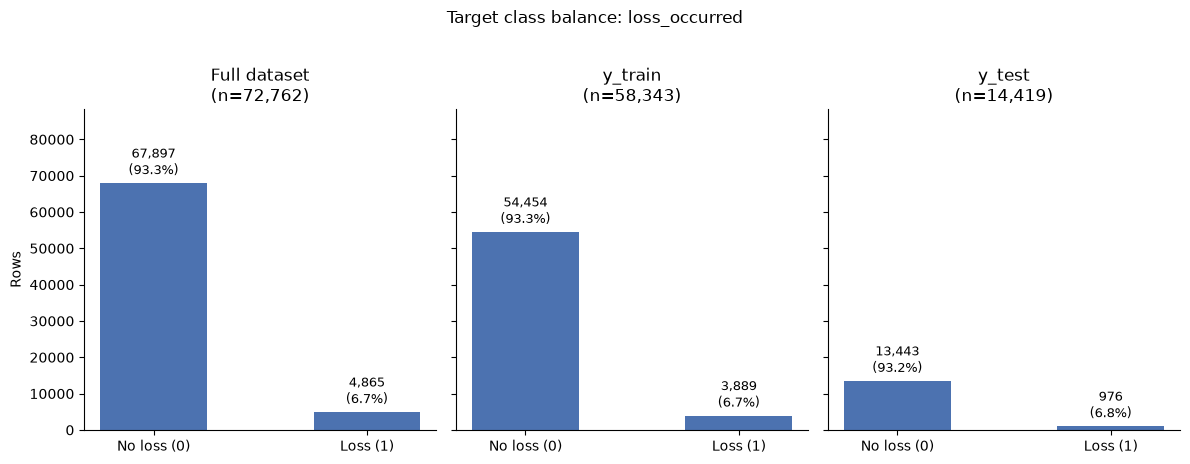

In [5]:
import matplotlib.pyplot as plt

BAR_COLOR = "#4C72B0"
LABELS = ["No loss (0)", "Loss (1)"]

datasets = [("Full dataset", df_model["loss_occurred"]), ("y_train", y_train), ("y_test", y_test)]

# sharey=True links all 3 axes to ONE y-limit -- compute it once up front
# from the largest panel (always "Full dataset", since train/test are
# subsets of it), rather than per-axis inside the loop, or each ax.set_ylim
# call overwrites the shared scale and clips the earlier (larger) panels'
# bars, leaving their labels floating above the visible plot area.
global_max = max(series.value_counts().max() for _, series in datasets)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=True)
for ax, (title, series) in zip(axes, datasets):
    counts = series.value_counts().reindex([0, 1])
    pct = counts / counts.sum() * 100
    bars = ax.bar(LABELS, counts.values, color=BAR_COLOR, width=0.5)
    ax.set_title(f"{title}\n(n={len(series):,})")
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val, p in zip(bars, counts.values, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + global_max * 0.02,
                 f"{val:,}\n({p:.1f}%)", ha="center", va="bottom", fontsize=9)

axes[0].set_ylim(0, global_max * 1.3)
axes[0].set_ylabel("Rows")
fig.suptitle("Target class balance: loss_occurred", y=1.02)
plt.tight_layout()
plt.show()

## Baseline model — Random Forest

Chosen over Logistic Regression: after one-hot encoding, `X_train` has 144
columns (~120+ sparse `crop_name` dummies plus region/year), and the
relationships we'd expect (rainfall thresholds, crop×region interactions)
are unlikely to be linear. Random Forest handles that kind of nonlinear,
interaction-heavy tabular data natively, needs no feature scaling, and its
feature importances will be useful later for explaining *why* a household
is flagged high-risk. `class_weight="balanced"` counters the 93.3%/6.7%
imbalance shown above (without it, the model would gravitate toward always
predicting "no loss"). A colleague will add XGBoost separately using the
same `X_train`/`X_test`/`y_train`/`y_test`, to compare against this
baseline.

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Random Forest fit on X_train/y_train.")

Random Forest fit on X_train/y_train.


## Evaluate — precision, recall, F1, ROC-AUC (not accuracy)

Accuracy is misleading on this dataset: a model that always predicts "no
loss" already scores ~93%. Evaluating on the **loss (1)** class's precision/
recall/F1, plus ROC-AUC, is what actually distinguishes a useful early-
warning model from a useless one.

In [7]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(classification_report(y_test, y_pred, target_names=["No loss", "Loss"]))
print(f"ROC-AUC: {auc:.3f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred)}")

              precision    recall  f1-score   support

     No loss       0.96      0.79      0.87     13443
        Loss       0.17      0.58      0.26       976

    accuracy                           0.78     14419
   macro avg       0.57      0.69      0.57     14419
weighted avg       0.91      0.78      0.83     14419

ROC-AUC: 0.750
Confusion matrix:
[[10659  2784]
 [  411   565]]


### Reading the results

**Confusion matrix** (rows = actual, columns = predicted):

|                  | Predicted No loss | Predicted Loss |
|------------------|-------------------:|----------------:|
| **Actual No loss** | 10,659 (true negatives) | 2,784 (false positives) |
| **Actual Loss**     | 411 (false negatives)   | 565 (true positives) |

- **Recall (loss) = 0.58**: of the 976 households that actually had a crop
  loss, the model correctly flags 565 of them. For an early-warning tool,
  missing a real loss (a false negative) is the costlier mistake, so this is
  the number that matters most.
- **Precision (loss) = 0.17**: of every row the model flags as "at risk,"
  only ~1 in 6 actually had a loss — a direct side effect of
  `class_weight="balanced"` pushing the model to flag more aggressively so
  it can catch more true positives. Expected for a first baseline, not a
  bug — a probability-threshold adjustment or a different imbalance
  strategy (e.g. SMOTE) can trade some recall back for precision later.
- **ROC-AUC = 0.750**: measures how well the model ranks actual-loss rows
  above no-loss rows across *all* possible thresholds (0.5 = random
  guessing, 1.0 = perfect separation) — independent of the specific
  threshold used above, so it's the fairest single number for comparing
  this baseline against a colleague's XGBoost model later.

## Plot — feature importance

A sanity check as much as an insight: confirms the model is actually
leaning on rainfall/crop/region/household signal rather than something
spurious, and previews what an eventual "why is this flagged" explanation
in the app would draw on. Top 15 features by mean decrease in impurity
(scikit-learn's default `RandomForestClassifier` importance).

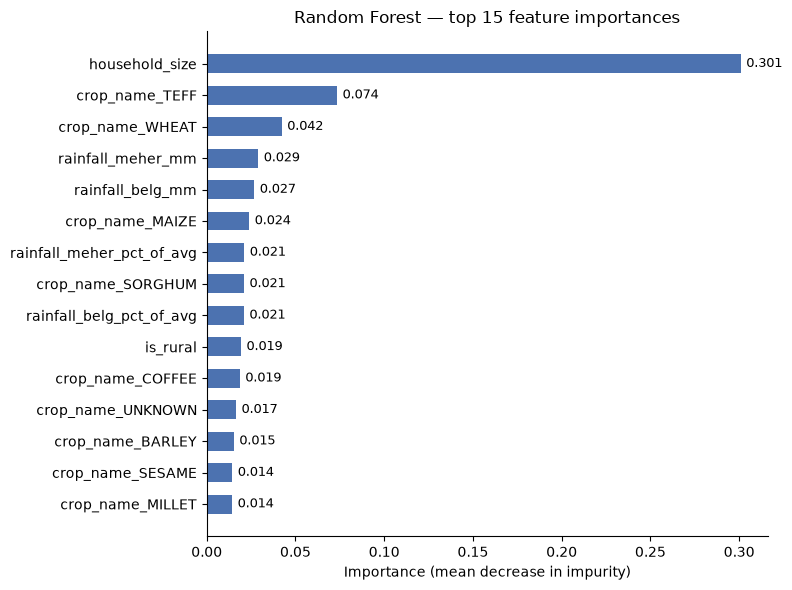

In [8]:
BAR_COLOR = "#4C72B0"
TOP_N = 15

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_importances = importances.head(TOP_N).sort_values()  # ascending so the largest bar ends up on top

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_importances.index, top_importances.values, color=BAR_COLOR, height=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title(f"Random Forest — top {TOP_N} feature importances")
for bar, val in zip(bars, top_importances.values):
    ax.text(val + importances.max() * 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Note for the team:** Two importance methods were run on this baseline —
scikit-learn's default MDI (Mean Decrease in Impurity, training-data-based)
and permutation importance (test-set-based, unbiased by feature
cardinality) — and they disagree substantially. MDI ranked `household_size`
first by a wide margin (0.30); permutation importance drops it to #7
(0.006) and puts `crop_name_TEFF` first instead (0.054), confirming MDI's
known bias toward continuous features. **Treat the permutation ranking as
the more trustworthy one.**

Two things worth flagging: (1) the seasonal rainfall features don't make
the permutation top 15 at all, despite being central to the project's
pitch — worth a closer look before we finalize the feature set; (2) two
`region_code` dummies (15, 12) show up under permutation importance that
weren't notable under MDI. When comparing against XGBoost, please use its
permutation importance (or SHAP) rather than its default `gain`/`weight`
importance, so we're comparing rankings on the same basis across models.
Reassuringly, no target-leakage columns show up in either ranking.

## Plot — permutation importance (validating the MDI ranking)

The plot above uses scikit-learn's default `feature_importances_` (Mean
Decrease in Impurity), which is computed from training data and is known to
be biased toward continuous/high-cardinality features (like
`household_size`) over one-hot binary dummies (like `crop_name_TEFF`) —
it's a first look, not proof. **Permutation importance** is the more
trustworthy check: computed on the held-out test set, it shuffles one
feature at a time and measures how much ROC-AUC actually drops, so it's
unbiased by cardinality and reflects real predictive contribution rather
than a training-time artifact.

/Users/ashenafi/.pyenv/versions/harvestguard/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


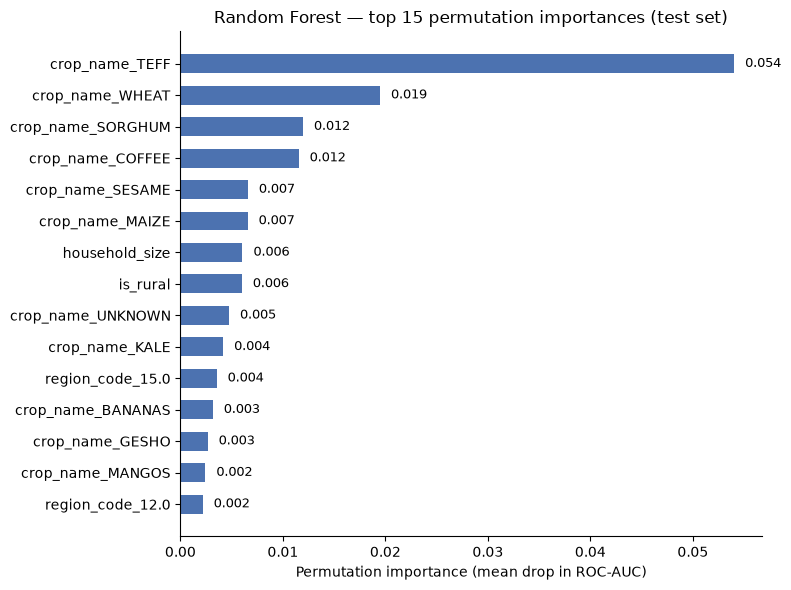

In [9]:
from sklearn.inspection import permutation_importance

BAR_COLOR = "#4C72B0"
TOP_N = 15

perm_result = permutation_importance(
    rf, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1
)
perm_importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
top_perm = perm_importances.head(TOP_N).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_perm.index, top_perm.values, color=BAR_COLOR, height=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("Permutation importance (mean drop in ROC-AUC)")
ax.set_title(f"Random Forest — top {TOP_N} permutation importances (test set)")
for bar, val in zip(bars, top_perm.values):
    ax.text(val + top_perm.max() * 0.02, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()